# Setup and Libraries

In [8]:
# Cell 0: get current notebook path, its parent, and project root (parent of parent)
import os
from pathlib import Path

# Data manipulation
import pandas as pd
import matplotlib.pyplot as plt

# Visualization
import seaborn as sns

# Optional: improve plots appearance
sns.set(style="whitegrid")

ROOT_DIR = Path(os.getcwd()).resolve().parent


# Load the CSV and json for participants

In [9]:
# CSV_PATH = Path("/home/falconnier/Downloads/idaSearch_5_29_2026.csv")
# CSV_PATH = Path(
#     "/run/media/falconnier/bb9ecfb7-b58f-41e9-a37d-fda12951eb4e/ADNI_T1w_curated/ADNI_T1w_idaSearch_5_29_2026_upgraded.csv"
# )  # HAS NEW COLUMNS, session, subject, age_at_visit
CSV_PATH = Path(
    "/home/falconnier/Documents/data/meta_data/ADNI_T1w_idaSearch_5_29_2026.csv"
)
# CSV_PATH = Path(
#     "/home/falconnier/Documents/data/meta_data/PPMI_idaSearch_6_12_2026.csv"
# )

assert CSV_PATH.exists(), f"Dataset directory {CSV_PATH} does not exist."


In [10]:
df = pd.read_csv(CSV_PATH)
print(display(df.head(5)))
print(df.columns)
# print(df["PATNO"].nunique())
# print(df[df["PATNO"] == 3000])

,Subject ID,Project,Phase,Sex,Weight,Research Group,Visit,Archive Date,Study Date,Age,Modality,Description,Imaging Protocol,Image ID
0,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,B1-Calibration Body,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13710
1,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,B1-Calibration PA,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13711
2,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=AXIAL;Mfg Model=SIGNA EXCITE...,13712
3,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=CORONAL;Mfg Model=SIGNA EXCI...,13713
4,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13714


None
Index(['Subject ID', 'Project', 'Phase', 'Sex', 'Weight', 'Research Group',
       'Visit', 'Archive Date', 'Study Date', 'Age', 'Modality', 'Description',
       'Imaging Protocol', 'Image ID'],
      dtype='object')


In [11]:
df["subject"] = df["Subject ID"]  # create a 'subject' column for easier reference
df["age_at_visit"] = df["Age"]
df["diagnosis"] = df["Research Group"]
df["session"] = pd.to_datetime(df["Study Date"]).dt.strftime(
    "%Y%m%d"
)  # YYYYMMDD format for session
df.head(5)
# print(df[df["subject"] == "002_S_0295"]["session"].unique())

,Subject ID,Project,Phase,Sex,Weight,Research Group,Visit,Archive Date,Study Date,Age,Modality,Description,Imaging Protocol,Image ID,subject,age_at_visit,diagnosis,session
0,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,B1-Calibration Body,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13710,002_S_0295,84.9,CN,20060418
1,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,B1-Calibration PA,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13711,002_S_0295,84.9,CN,20060418
2,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=AXIAL;Mfg Model=SIGNA EXCITE...,13712,002_S_0295,84.9,CN,20060418
3,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=CORONAL;Mfg Model=SIGNA EXCI...,13713,002_S_0295,84.9,CN,20060418
4,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13714,002_S_0295,84.9,CN,20060418


In [12]:
# Count and print duplicates for ["subject", "session"]
duplicates_session = df.duplicated(subset=["subject", "session"], keep=False).sum()
print(f"Number of duplicate rows for ['subject', 'session']: {duplicates_session}")

# Count and print duplicates for ["subject", "age_at_visit"]
duplicates_age = df.duplicated(subset=["subject", "age_at_visit"], keep=False).sum()
print(f"Number of duplicate rows for ['subject', 'age_at_visit']: {duplicates_age}")

# Drop duplicates for ["subject", "session"]
df_to_save = df.drop_duplicates(subset=["subject", "session"], keep="first")

# Drop duplicates for ["subject", "age_at_visit"]
df_to_save = df_to_save.drop_duplicates(
    subset=["subject", "age_at_visit"], keep="first"
)

# Assert no duplicates remain
assert not df_to_save.duplicated(["subject", "session"]).any(), (
    "Duplicates still exist for ['subject', 'session']"
)
assert not df_to_save.duplicated(["subject", "age_at_visit"]).any(), (
    "Duplicates still exist for ['subject', 'age_at_visit']"
)

print(df_to_save["subject"].nunique())

Number of duplicate rows for ['subject', 'session']: 128957
Number of duplicate rows for ['subject', 'age_at_visit']: 128958
3207


diagnosis
MCI    4014
AD     1414
Name: count, dtype: int64


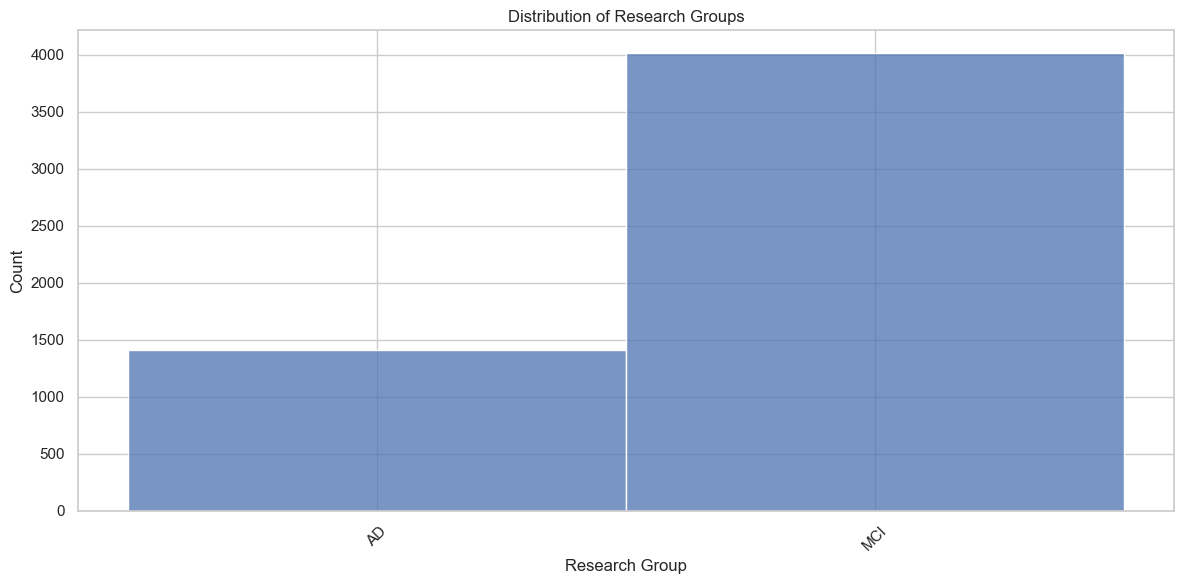

In [13]:
# plot histogran of column "session"
# df_to_save = df_to_save[(df_to_save["Research Group"].isin(["CN", "AD"]))].copy()
df_to_save = df_to_save[(df_to_save["Research Group"].isin(["MCI", "AD"]))].copy()
# df_to_save = df_to_save[(df_to_save["Research Group"].isin(["AD"]))].copy()
# df_to_save = df_to_save[(df_to_save["diagnosis"].isin(["CN"]))].copy()
# df_to_save = df_to_save[(df_to_save["diagnosis"].isin(["PD", "Control"]))].copy()
# df_to_save = df_to_save[(df_to_save["diagnosis"].isin(["PD"]))].copy()
# df_to_save = df_to_save[(df_to_save["diagnosis"].isin(["Control"]))].copy()

print(df_to_save["diagnosis"].value_counts())

plt.figure(figsize=(12, 6))
sns.histplot(df_to_save["diagnosis"], bins=30, kde=False)
plt.title("Distribution of Research Groups")
plt.xlabel("Research Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# output_path = CSV_PATH.parent / f"{CSV_PATH.stem}_upgraded.csv"
# output_path = CSV_PATH.parent / f"{CSV_PATH.stem}_AD_CN_noageduplicates.csv"
# output_path = CSV_PATH.parent / f"{CSV_PATH.stem}_CN_noageduplicates.csv"
# output_path = CSV_PATH.parent / "ADNI_CN_AD.csv"
# output_path = CSV_PATH.parent / "ADNI_AD.csv"
output_path = CSV_PATH.parent / "ADNI_AD_MCI.csv"
# output_path = CSV_PATH.parent / "PPMI_CN_PD.csv"
# output_path = CSV_PATH.parent / "PPMI_PD.csv"
# output_path = CSV_PATH.parent / "PPMI_CN.csv"

df_to_save.to_csv(output_path, index=False)
print(f"DataFrame saved to {output_path}")
print(df_to_save[["subject", "session", "age_at_visit"]].head(5))
print(df_to_save[["subject", "session", "age_at_visit"]].head(5).dtypes)

DataFrame saved to /home/falconnier/Documents/data/meta_data/ADNI_AD_MCI.csv
        subject   session  age_at_visit
320  002_S_0619  20060601          77.6
332  002_S_0619  20061213          78.1
341  002_S_0619  20070622          78.6
347  002_S_0619  20080813          79.8
422  002_S_0729  20060717          65.3
subject          object
session          object
age_at_visit    float64
dtype: object
